# Project 1 - How much of the pairs alpha survives multiple testing?

Four separate attacks on the result:

| # | Test | Question it answers |
|---|---|---|
| 1 | Expected false discoveries / Bonferroni / Benjamini-Hochberg | How many survivors are statistical noise? |
| 2 | Probabilistic & Deflated Sharpe Ratio | Is the Sharpe significant *after* charging for the search? |
| 3 | Random-walk null universe | How many "cointegrated" pairs does the screener find in data with no structure at all? |
| 4 | Block-bootstrap null | How good does a Sharpe like ours look when cointegration is destroyed but everything else is kept? |

References: Bailey & Lopez de Prado (2014) on the Deflated Sharpe Ratio, Harvey, Liu & Zhu
(2016) on multiple testing in finance, Benjamini & Hochberg (1995) on FDR.

## 1. Setup

In [18]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.stats import norm, skew, kurtosis
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams['figure.figsize'] = (12, 5)

In [19]:
start_date = "2020-01-07"
end_date   = "2026-01-07"

min_correlation = 0.8
adf_alpha = 0.05

comission = 1.0
slippage = 2.0
cost_bps = comission + slippage # 3 bps total

lookback = 60
entry_z = 2.0

n_null_universes = 20
n_bootstrap = 100

universe = [
    'AAPL', 'MSFT', 'GOOGL', 'META', 'NVDA', 'AMD', 'INTC', 'ORCL', 'CRM', 'ADBE',
    'JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'USB', 'PNC',
    'XOM', 'CVX', 'COP', 'SLB', 'PSX', 'VLO',
    'DUK', 'PPL', 'SO', 'AEP', 'D', 'EXC', 'XEL', 'ED',
    'JNJ', 'PFE', 'MRK', 'ABBV', 'LLY', 'BMY',
    'KO', 'PEP', 'PG', 'CL', 'WMT', 'TGT', 'HD', 'LOW', ]

In [20]:
def download_adjusted_closes(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)

    if isinstance(raw.columns, pd.MultiIndex):
        field = 'Adj Close' if 'Adj Close' in raw.columns.levels[0] else 'Close'
        px = raw[field]
    else:
        px = raw[['Adj Close']] if 'Adj Close' in raw.columns else raw[['Close']]
        px.columns = [tickers] if isinstance(tickers, str) else tickers

    return px.dropna(axis=1, how='all').sort_index()

In [21]:
data = download_adjusted_closes(universe, start_date, end_date).dropna()

print(f"{data.shape[1]} tickers, {len(data)} trading days, ")
print("\n")
print(f"{data.shape[1] * (data.shape[1] - 1) // 2} candidate pairs")

data.tail()

46 tickers, 1508 trading days, 


1035 candidate pairs


Ticker,AAPL,ABBV,ADBE,AEP,AMD,BAC,BMY,C,CL,COP,...,PSX,SLB,SO,TGT,USB,VLO,WFC,WMT,XEL,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-30,272.338684,224.433655,352.510010,113.387085,215.339996,54.685120,52.438114,115.466187,78.090317,92.070465,...,126.903786,38.124115,85.468269,94.818573,52.788486,162.455215,92.782570,111.211792,73.094376,118.610596
2025-12-31,271.122009,223.212524,349.989990,112.722343,214.160004,54.408131,52.176941,114.953926,77.609062,91.591034,...,126.394447,37.955994,85.107155,95.129997,52.366489,160.415390,91.690536,110.705017,72.769249,117.973373
2026-01-02,270.274323,224.013580,333.299988,113.211128,223.470001,55.347912,52.323753,116.934021,76.302818,94.614380,...,127.893089,39.755886,85.087631,97.816017,52.925877,162.898636,93.658150,112.046478,73.577133,120.237953
2026-01-05,266.534515,215.094452,331.559998,111.510170,221.080002,56.277790,51.932259,121.465584,75.556381,97.060463,...,137.110153,43.316116,84.785080,99.363396,54.456833,177.936050,94.819038,111.996788,72.976143,122.894653
2026-01-06,261.647797,218.757843,335.989990,112.458412,214.350006,56.633919,53.263348,120.677483,75.821556,95.015541,...,133.848434,43.147995,85.419472,101.504433,55.035851,175.669601,94.828880,113.616463,73.330833,118.669426


## 2. Instrument the screener

In [22]:
def screen_universe(prices, log_all=True):
    returns = prices.pct_change().dropna(how='all')
    corr = returns.corr()
    cols = list(corr.columns)

    adf_cache = {c: adfuller(prices[c].dropna())[1] for c in cols}

    rows = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            c = corr.iloc[i, j]

            rec = {'first': a, 'second': b, 'corr': c,
                   'p_adf_first': adf_cache[a], 'p_adf_second': adf_cache[b],
                   'p_adf_resid': np.nan, 'beta': np.nan,
                   'passed_corr': False, 'passed_legs': False, 'passed': False}

            if not (min_correlation <= c < 1):
                if log_all:
                    rows.append(rec)
                continue
            rec['passed_corr'] = True

            if not (adf_cache[a] > adf_alpha and adf_cache[b] > adf_alpha):
                if log_all:
                    rows.append(rec)
                continue
            rec['passed_legs'] = True

            aligned = prices[[a, b]].dropna()
            X = sm.add_constant(aligned[b])
            res = sm.OLS(aligned[a], X).fit()

            rec['beta'] = res.params.iloc[1]
            rec['p_adf_resid'] = adfuller(res.resid)[1]
            rec['passed'] = rec['p_adf_resid'] < adf_alpha
            rows.append(rec)

    return pd.DataFrame(rows)


screen_log = screen_universe(data)

n_tested = len(screen_log)
n_corr = screen_log['passed_corr'].sum()
n_legs = screen_log['passed_legs'].sum()
n_passed = screen_log['passed'].sum()

print(f"Pairs tested: {n_tested}")
print(f"survived correlation >= {min_correlation} : {n_corr}")
print(f"both legs I(1) : {n_legs}")
print(f"residuals I(0) [TRADABLE]: {n_passed}")

Pairs tested: 1035
survived correlation >= 0.8 : 34
both legs I(1) : 34
residuals I(0) [TRADABLE]: 5


## 3. Test 1 - how many survivors are noise?

Three views of the same question.

- **Expected false discoveries.** Under the null of no cointegration, the residual ADF test
  rejects at rate `adf_alpha` by construction. Multiply by the number of pairs that reached
  that stage.
- **Bonferroni.** Control the family-wise error rate: require `p < alpha / m`. Brutally
  conservative, but if a pair survives it, it is real.
- **Benjamini-Hochberg.** Control the false discovery rate instead - the sensible middle
  ground. Accept that some survivors are false, but cap the expected *proportion*.

In [23]:
def benjamini_hochberg(pvalues, alpha=0.05):
    p = np.asarray(pvalues, dtype=float)
    ok = ~np.isnan(p)
    m = ok.sum()
    if m == 0:
        return np.zeros(len(p), dtype=bool)

    order = np.argsort(np.where(ok, p, np.inf))
    ranked = p[order][:m]
    thresholds = alpha * np.arange(1, m + 1) / m
    below = ranked <= thresholds

    mask = np.zeros(len(p), dtype=bool)
    if below.any():
        cutoff_rank = np.max(np.where(below)[0])
        mask[order[:cutoff_rank + 1]] = True
    return mask


tested_resid = screen_log[screen_log['passed_legs']].copy()
m = len(tested_resid)

m_safe = max(m, 1)
expected_false = m * adf_alpha
bonferroni_hits = (tested_resid['p_adf_resid'] < adf_alpha / m_safe).sum()
bh_mask = benjamini_hochberg(tested_resid['p_adf_resid'].values, alpha=adf_alpha)
bh_hits = bh_mask.sum()

summary = pd.DataFrame([
    ['Pairs reaching the residual test', m],
    ['Naive discoveries (p < 0.05)', int(n_passed)],
    ['Expected FALSE discoveries under the null', round(expected_false, 1)],
    ['Implied share of survivors that are noise', f"{expected_false / max(n_passed, 1):.0%}"],
    [f'Bonferroni survivors (p < {adf_alpha}/{m_safe})', int(bonferroni_hits)],
    ['Benjamini-Hochberg survivors (FDR 5%)', int(bh_hits)], ], columns=['', 'Value']).set_index('')

tested_resid['bh_pass'] = bh_mask
robust_pairs = [tuple(r) for r in
                tested_resid.loc[tested_resid['bh_pass'], ['first', 'second']].values]
naive_pairs  = [tuple(r) for r in
                screen_log.loc[screen_log['passed'], ['first', 'second']].values]

In [24]:
summary

,Value
,
Pairs reaching the residual test,34
Naive discoveries (p < 0.05),5
Expected FALSE discoveries under the null,1.7
Implied share of survivors that are noise,34%
Bonferroni survivors (p < 0.05/34),0
Benjamini-Hochberg survivors (FDR 5%),0


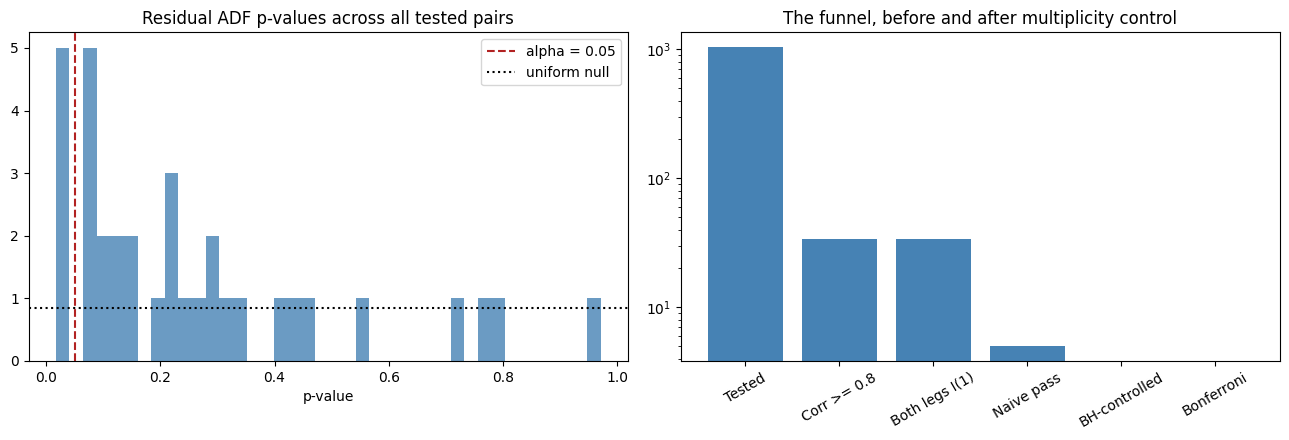

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(tested_resid['p_adf_resid'].dropna(), bins=40, color='steelblue', alpha=0.8)
axes[0].axvline(adf_alpha, color='firebrick', linestyle='--', label='alpha = 0.05')
axes[0].axhline(m_safe / 40, color='black', linestyle=':', label='uniform null')
axes[0].set_title('Residual ADF p-values across all tested pairs')
axes[0].set_xlabel('p-value')
axes[0].legend()

funnel = pd.Series({'Tested': n_tested, 'Corr >= 0.8': n_corr,
                    'Both legs I(1)': n_legs, 'Naive pass': n_passed,
                    'BH-controlled': bh_hits, 'Bonferroni': bonferroni_hits})
axes[1].bar(funnel.index, funnel.values, color='steelblue')
axes[1].set_yscale('log')
axes[1].set_title('The funnel, before and after multiplicity control')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Test 2 - Probabilistic and Deflated Sharpe Ratio

The Sharpe ratio of the *selected* strategy is biased upward by the search itself. Bailey &
Lopez de Prado's correction has two parts:

**Probabilistic Sharpe (PSR)** - the probability that the true Sharpe exceeds a benchmark,
correcting for the skew and fat tails of the return distribution (a Sharpe built on negatively
skewed, kurtotic returns is worth less than the same number on Gaussian returns):

$$\widehat{PSR}(SR^*) = \Phi\left[\frac{(\widehat{SR} - SR^*)\sqrt{T-1}}{\sqrt{1 - \gamma_3\widehat{SR} + \frac{\gamma_4-1}{4}\widehat{SR}^2}}\right]$$

**Deflated Sharpe (DSR)** - the same thing, but with the benchmark $SR^*$ set to the Sharpe you
would *expect* to find by chance as the maximum over $N$ independent trials:

$$SR^* = \sqrt{V[\widehat{SR}_n]}\left[(1-\gamma)\Phi^{-1}\left(1-\tfrac{1}{N}\right) + \gamma\,\Phi^{-1}\left(1-\tfrac{1}{Ne}\right)\right]$$

with $\gamma$ the Euler-Mascheroni constant. The variance term is measured across the trials we
actually ran, which is why logging the rejects mattered.

In [26]:
def backtest_spread(p1, p2, beta_series, lookback=60, entry_z=2.0, exit_z=0.0,
                    stop_z=4.0, cost_bps=3.0):
    spread = p1 - beta_series * p2
    mu = spread.rolling(lookback).mean()
    sd = spread.rolling(lookback).std()
    z = ((spread - mu) / sd).replace([np.inf, -np.inf], np.nan)

    zv = z.values
    pos = np.zeros(len(zv))
    state = 0
    for t in range(1, len(zv)):
        if np.isnan(zv[t]):
            state = 0
        elif state == 0:
            if zv[t] > entry_z:
                state = -1          # spread too rich => sell
            elif zv[t] < -entry_z:
                state = 1           # spread too cheap => buy
        else:
            if abs(zv[t]) > stop_z:
                state = 0           # it kept going => get out
            elif state == 1 and zv[t] >= exit_z:
                state = 0           # reverted => take profit
            elif state == -1 and zv[t] <= exit_z:
                state = 0
        pos[t] = state

    pos = pd.Series(pos, index=z.index)

    notional = (p1.abs() + (beta_series * p2).abs())
    gross = pos.shift(1) * spread.diff()
    turnover = pos.diff().abs().fillna(0)
    cost = turnover * notional * cost_bps / 10_000

    ret = ((gross - cost) / notional.shift(1)).replace([np.inf, -np.inf], np.nan).fillna(0)
    return ret, pos


def sharpe(returns, periods_per_year=252):
    r = pd.Series(returns).dropna()
    if r.std() == 0 or len(r) < 2:
        return np.nan
    return r.mean() / r.std() * np.sqrt(periods_per_year)

In [27]:
def static_beta_series(p1, p2):
    X = sm.add_constant(p2)
    b = sm.OLS(p1, X).fit().params.iloc[1]
    return pd.Series(b, index=p1.index)


def run_pairs(prices, pairs, **kwargs):
    out = {}
    for a, b in pairs:
        aligned = prices[[a, b]].dropna()
        if len(aligned) < lookback * 2:
            continue
        p1, p2 = aligned[a], aligned[b]
        ret, _ = backtest_spread(p1, p2, static_beta_series(p1, p2),
                                 lookback=lookback, entry_z=entry_z,
                                 cost_bps=cost_bps, **kwargs)
        out[f"{a}-{b}"] = ret
    return pd.DataFrame(out)

all_candidates = [tuple(r) for r in tested_resid[['first', 'second']].values]
all_returns = run_pairs(data, all_candidates)

if all_returns.empty:
    raise RuntimeError("No pair reached the residual test, so there is nothing to audit. Widen the universe, lower min_correlation, or lengthen the sample.")

sr_all = all_returns.apply(sharpe).dropna()
print(f"Backtested {len(sr_all)} trials")
print(f"Sharpe across trials: mean {sr_all.mean():.2f}, sd {sr_all.std():.2f},")
print(f"max {sr_all.max():.2f}")

Backtested 34 trials
Sharpe across trials: mean 0.16, sd 0.31,
max 0.94


In [28]:
def probabilistic_sharpe(returns, sr_benchmark=0.0, periods_per_year=252):
    r = pd.Series(returns).dropna()
    T = len(r)
    sr = r.mean() / r.std()                
    sr0 = sr_benchmark / np.sqrt(periods_per_year)
    g3 = skew(r)
    g4 = kurtosis(r, fisher=False)

    num = (sr - sr0) * np.sqrt(T - 1)
    den = np.sqrt(max(1 - g3 * sr + (g4 - 1) / 4 * sr ** 2, 1e-12))
    return norm.cdf(num / den)


def expected_max_sharpe(sr_variance_annual, n_trials):
    gamma = 0.5772156649
    if n_trials < 2:
        return 0.0
    return np.sqrt(sr_variance_annual) * (
        (1 - gamma) * norm.ppf(1 - 1 / n_trials)
        + gamma * norm.ppf(1 - 1 / (n_trials * np.e))
    )

In [29]:
naive_cols  = [f"{a}-{b}" for a, b in naive_pairs if f"{a}-{b}" in all_returns.columns]
robust_cols = [f"{a}-{b}" for a, b in robust_pairs if f"{a}-{b}" in all_returns.columns]

portfolios = {
    'Naive screener (p < 0.05)': (all_returns[naive_cols].mean(axis=1)
                                  if naive_cols else pd.Series(dtype=float)),
    'BH-controlled (FDR 5%)': (all_returns[robust_cols].mean(axis=1)
                               if robust_cols else pd.Series(dtype=float)),
    'Best single pair (the cherry-pick)': all_returns[sr_all.idxmax()],
}

# Everything downstream keys off the naive book, so make sure it exists
naive_book = portfolios['Naive screener (p < 0.05)']

n_trials = len(sr_all)
sr_star = expected_max_sharpe(sr_all.var(), n_trials)

rows = []
for name, r in portfolios.items():
    if r.empty:
        rows.append({'Strategy': name, 'Sharpe (ann.)': 'n/a', 'PSR vs 0': 'n/a',
                     'DSR': 'n/a', 'Verdict': 'no survivors'})
        continue
    s = sharpe(r)
    psr = probabilistic_sharpe(r, 0.0)
    dsr = probabilistic_sharpe(r, sr_star)
    rows.append({
        'Strategy': name,
        'Sharpe (ann.)': f"{s:.2f}",
        'PSR vs 0': f"{psr:.1%}",
        'DSR': f"{dsr:.1%}",
        'Verdict': 'survives' if dsr > 0.95 else 'NOT significant after the search',
    })

print(f"Trials run (N): {n_trials}")
print(f"SD of Sharpe across trials: {sr_all.std():.2f}")
print(f"Expected max Sharpe by luck alone: {sr_star:.2f}")
pd.DataFrame(rows).set_index('Strategy')

Trials run (N): 34
SD of Sharpe across trials: 0.31
Expected max Sharpe by luck alone: 0.66


,Sharpe (ann.),PSR vs 0,DSR,Verdict
Strategy,,,,
Naive screener (p < 0.05),0.69,95.7%,53.4%,NOT significant after the search
BH-controlled (FDR 5%),n/a,n/a,n/a,no survivors
Best single pair (the cherry-pick),0.94,99.0%,76.1%,NOT significant after the search


## 5. Test 3 - point the screener at pure noise

We generate a universe of independent geometric random walks with no cointegration whatsoever, run the identical screener, and count how many "tradable pairs" it reports.

Whatever it finds is 100% false positive, by construction.

In [30]:
def synthetic_universe(n_names, n_days, index, vol=0.015, factor_loading=0.8, seed=None):
    r = np.random.default_rng(seed)
    factor = r.normal(0, vol, size=(n_days, 1))
    idio = r.normal(0, vol, size=(n_days, n_names))
    shocks = factor_loading * factor + np.sqrt(1 - factor_loading ** 2) * idio
    prices = 100 * np.exp(np.cumsum(shocks, axis=0))
    return pd.DataFrame(prices, index=index,
                        columns=[f"RW{i:02d}" for i in range(n_names)])

real_corr = data.pct_change().corr()
off_diag = real_corr.values[np.triu_indices_from(real_corr.values, k=1)]

surviving = off_diag[off_diag >= min_correlation]
target_corr = surviving.mean() if len(surviving) else off_diag.mean()
calibrated_loading = float(np.clip(np.sqrt(max(target_corr, 0.01)), 0.1, 0.98))
print(f"Correlation of screened pairs, real universe: {target_corr:.2f} "
      f"-> factor loading {calibrated_loading:.2f}")

null_counts = []
for k in range(n_null_universes):
    fake = synthetic_universe(data.shape[1], len(data), data.index,
                              factor_loading=calibrated_loading, seed=1000 + k)
    log = screen_universe(fake)
    null_counts.append({
        'tested': len(log),
        'passed_corr': int(log['passed_corr'].sum()),
        'passed_legs': int(log['passed_legs'].sum()),
        'passed': int(log['passed'].sum()),
    })

null_df = pd.DataFrame(null_counts)
print("Screener output on pure random walks (all discoveries are false by construction)")
print(null_df.describe().loc[['mean', 'std', 'min', 'max']].round(1).to_string())
print()
print(f"Real universe found {n_passed} tradable pairs.")
print(f"Noise universe finds {null_df['passed'].mean():.1f} on average "
      f"({null_df['passed'].mean() / max(n_passed, 1):.0%} of the real count).")

Correlation of screened pairs, real universe: 0.83 -> factor loading 0.91
Screener output on pure random walks (all discoveries are false by construction)
      tested  passed_corr  passed_legs  passed
mean  1035.0       1035.0        915.4   153.4
std      0.0          0.0        239.5    85.7
min   1035.0       1035.0        105.0    10.0
max   1035.0       1035.0       1035.0   315.0

Real universe found 5 tradable pairs.
Noise universe finds 153.4 on average (3068% of the real count).


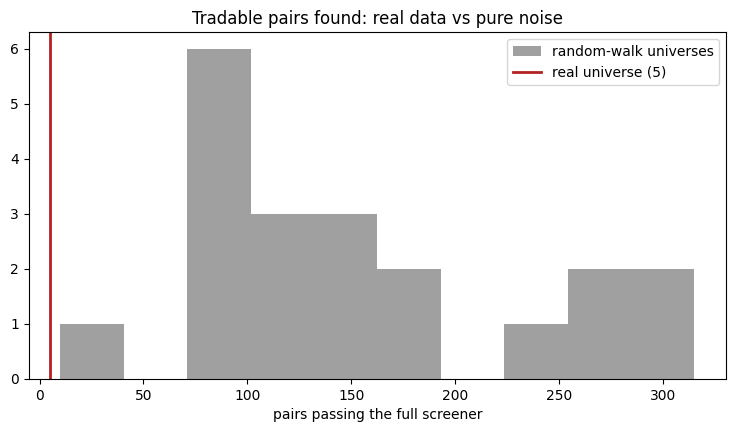

In [31]:
plt.figure(figsize=(9, 4.5))
plt.hist(null_df['passed'], bins=max(len(null_df) // 2, 5), color='grey', alpha=0.75, label='random-walk universes')

plt.axvline(n_passed, color='firebrick', lw=2, label=f'real universe ({n_passed})')
plt.title('Tradable pairs found: real data vs pure noise')
plt.xlabel('pairs passing the full screener')
plt.legend()

plt.show()

## 6. Test 4 - block bootstrap

In [32]:
def circular_block_bootstrap(returns, block=20, rng=None):
    # Resample blocks of returns with wraparound, preserving local dependence
    rng = rng or np.random.default_rng()
    n = len(returns)
    n_blocks = int(np.ceil(n / block))
    starts = rng.integers(0, n, size=n_blocks)
    idx = np.concatenate([(np.arange(s, s + block) % n) for s in starts])[:n]
    return returns.values[idx]


def bootstrap_null_sharpe(prices, pairs, n_draws, block=20, seed=7):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n_draws):
        rets = []
        for a, b in pairs:
            aligned = prices[[a, b]].dropna()
            if len(aligned) < lookback * 2:
                continue
            p1 = aligned[a]

            # Rebuild leg 2 from shuffled blocks of its own returns
            r2 = aligned[b].pct_change().dropna()
            shuffled = circular_block_bootstrap(r2, block=block, rng=rng)
            p2 = pd.Series(aligned[b].iloc[0] * np.cumprod(1 + shuffled),
                           index=aligned.index[1:]).reindex(aligned.index).bfill()

            ret, _ = backtest_spread(p1, p2, static_beta_series(p1, p2),
                                     lookback=lookback, entry_z=entry_z, cost_bps=cost_bps)
            rets.append(ret)

        if rets:
            out.append(sharpe(pd.concat(rets, axis=1).mean(axis=1)))

    return pd.Series(out).dropna()


null_sharpes = bootstrap_null_sharpe(data, naive_pairs, n_bootstrap)
observed_sharpe = sharpe(naive_book) if not naive_book.empty else np.nan

p_empirical = ((null_sharpes >= observed_sharpe).mean()
               if len(null_sharpes) and not np.isnan(observed_sharpe) else np.nan)

print(f"Observed portfolio Sharpe : {observed_sharpe:.2f}")
print(f"Bootstrap null: mean {null_sharpes.mean():.2f}, "
      f"95th pct {null_sharpes.quantile(0.95):.2f}, max {null_sharpes.max():.2f}")
print(f"Empirical p-value: {p_empirical:.3f}")

Observed portfolio Sharpe : 0.69
Bootstrap null: mean 0.23, 95th pct 0.59, max 0.77
Empirical p-value: 0.040


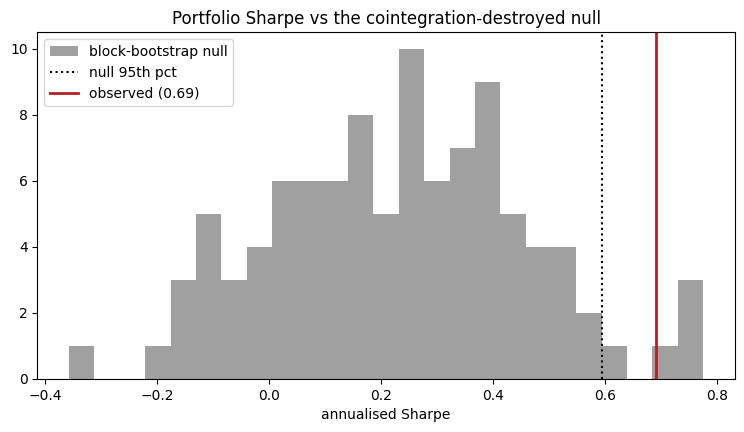

In [33]:
plt.figure(figsize=(9, 4.5))
plt.hist(null_sharpes, bins=max(len(null_sharpes) // 4, 5), color='grey', alpha=0.75,
         label='block-bootstrap null')
plt.axvline(null_sharpes.quantile(0.95), color='black', linestyle=':', label='null 95th pct')
plt.axvline(observed_sharpe, color='firebrick', lw=2,
            label=f'observed ({observed_sharpe:.2f})')
plt.title('Portfolio Sharpe vs the cointegration-destroyed null')
plt.xlabel('annualised Sharpe')
plt.legend()
plt.show()

## 7. Verdict

In [34]:
verdict = pd.DataFrame([
    ['Candidate pairs tested', f"{n_tested}"],
    ['Naive survivors', f"{n_passed}"],
    ['Expected false among them', f"{expected_false:.0f} ({expected_false / max(n_passed,1):.0%})"],
    ['Survivors after FDR control', f"{bh_hits}"],
    ['Survivors after Bonferroni', f"{bonferroni_hits}"],
    ['Pairs found in pure noise', f"{null_df['passed'].mean():.1f}"],
    ['Observed portfolio Sharpe', f"{observed_sharpe:.2f}"],
    ['Sharpe expected from luck alone (N trials)', f"{sr_star:.2f}"],
    ['Deflated Sharpe Ratio', f"{probabilistic_sharpe(naive_book, sr_star):.1%}" if not naive_book.empty else "n/a"],
    ['Bootstrap empirical p-value', f"{p_empirical:.3f}"],
], columns=['', 'Value']).set_index('')
verdict

,Value
,
Candidate pairs tested,1035
Naive survivors,5
Expected false among them,2 (34%)
Survivors after FDR control,0
Survivors after Bonferroni,0
Pairs found in pure noise,153.4
Observed portfolio Sharpe,0.69
Sharpe expected from luck alone (N trials),0.66
Deflated Sharpe Ratio,53.4%
